# Netflix Content & Viewership Analysis

**Author:** Data Analyst Portfolio Project  
**Dataset:** Netflix Movies and TV Shows (7,787 titles)  
**Goal:** Clean the raw catalog data, engineer useful features, and uncover trends in content type, country, genre, rating, and release patterns to help understand Netflix's content strategy.

## Table of Contents
1. Data Loading & Inspection
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis
5. Key Business Insights


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

df = pd.read_csv("../data/netflix_titles.csv")
print("Shape:", df.shape)
df.head()

Shape: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB


In [3]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

director        2389
cast             718
country          507
date_added        10
rating             7
title              0
show_id            0
type               0
release_year       0
duration           0
listed_in          0
description        0
dtype: int64

## 2. Data Cleaning

Steps taken:
- Fill missing `director`, `cast`, `country` with `"Not Specified"` (they're categorical text fields, dropping would lose too much data)
- Drop the small number of rows missing `rating` or `date_added` (critical fields, very few nulls)
- Convert `date_added` to proper datetime
- Remove duplicate titles


In [4]:
df["director"] = df["director"].fillna("Not Specified")
df["cast"] = df["cast"].fillna("Not Specified")
df["country"] = df["country"].fillna("Not Specified")

df = df.dropna(subset=["rating", "date_added"])

df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y")

before = len(df)
df = df.drop_duplicates(subset=["title", "type", "release_year"])
print(f"Removed {before - len(df)} duplicates")
print("Cleaned shape:", df.shape)

Removed 0 duplicates
Cleaned shape: (7770, 12)


## 3. Feature Engineering

New columns created for deeper analysis:
- `year_added`, `month_added` — from date_added
- `duration_value` / `duration_type` — numeric runtime split from Movies vs Seasons
- `primary_country` — first listed country
- `primary_genre` — first listed genre category
- `genre_count` — number of genres tagged to a title
- `days_release_to_add` — how long after release the title was added to Netflix


In [5]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

df["duration_type"] = np.where(df["type"] == "Movie", "min", "Season(s)")
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)

df["primary_country"] = df["country"].apply(lambda x: x.split(",")[0].strip())
df["primary_genre"] = df["listed_in"].apply(lambda x: x.split(",")[0].strip())
df["genre_count"] = df["listed_in"].apply(lambda x: len(x.split(",")))

df["days_release_to_add"] = (df["date_added"] - pd.to_datetime(df["release_year"], format="%Y")).dt.days

df.to_csv("../data/netflix_titles_cleaned.csv", index=False)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_type,duration_value,primary_country,primary_genre,genre_count,days_release_to_add
0,s1,TV Show,3%,Not Specified,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,August,Season(s),4.0,Brazil,International TV Shows,3,226
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,December,min,93.0,Mexico,Dramas,2,357
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,December,min,78.0,Singapore,Horror Movies,2,2910
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,November,min,80.0,United States,Action & Adventure,3,3241
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,January,min,123.0,United States,Dramas,1,4383


## 4. Exploratory Data Analysis

### 4.1 Movies vs TV Shows

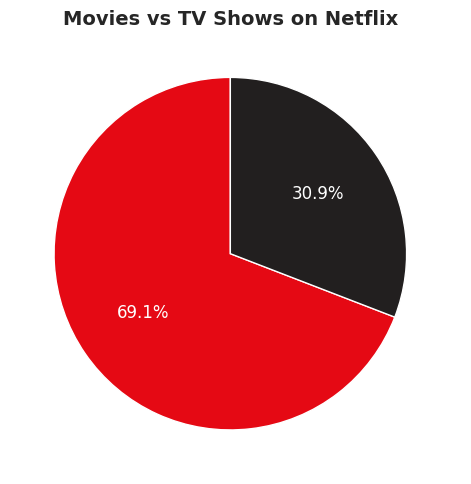

In [6]:
type_counts = df["type"].value_counts()
plt.figure(figsize=(6,5))
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
        colors=["#E50914", "#221f1f"], startangle=90,
        textprops={"color": "white", "fontsize": 12})
plt.title("Movies vs TV Shows on Netflix", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

### 4.2 Content Added Over the Years

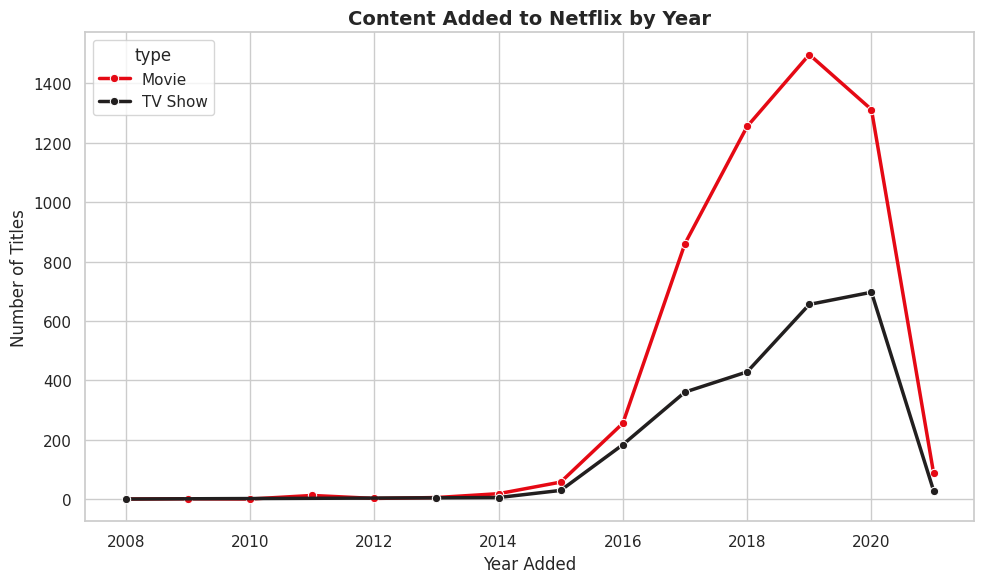

In [7]:
yearly = df.groupby(["year_added", "type"]).size().reset_index(name="count")
plt.figure(figsize=(10,6))
sns.lineplot(data=yearly, x="year_added", y="count", hue="type",
             marker="o", palette=["#E50914", "#221f1f"], linewidth=2.5)
plt.title("Content Added to Netflix by Year", fontsize=14, weight="bold")
plt.xlabel("Year Added"); plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

### 4.3 Top 10 Countries by Content

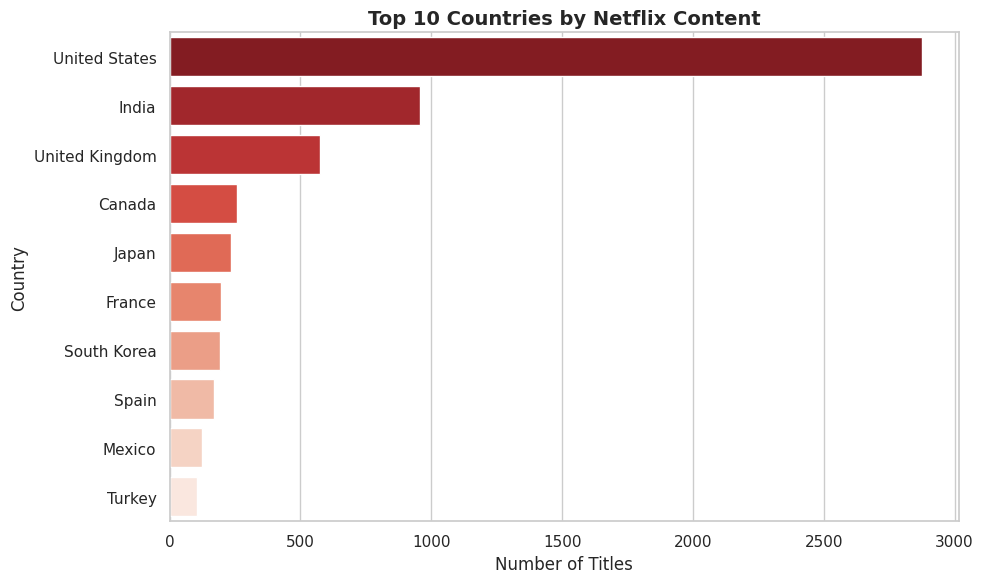

In [8]:
top_countries = df[df["primary_country"] != "Not Specified"]["primary_country"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette="Reds_r", legend=False)
plt.title("Top 10 Countries by Netflix Content", fontsize=14, weight="bold")
plt.xlabel("Number of Titles"); plt.ylabel("Country")
plt.tight_layout()
plt.show()

### 4.4 Content Rating Distribution

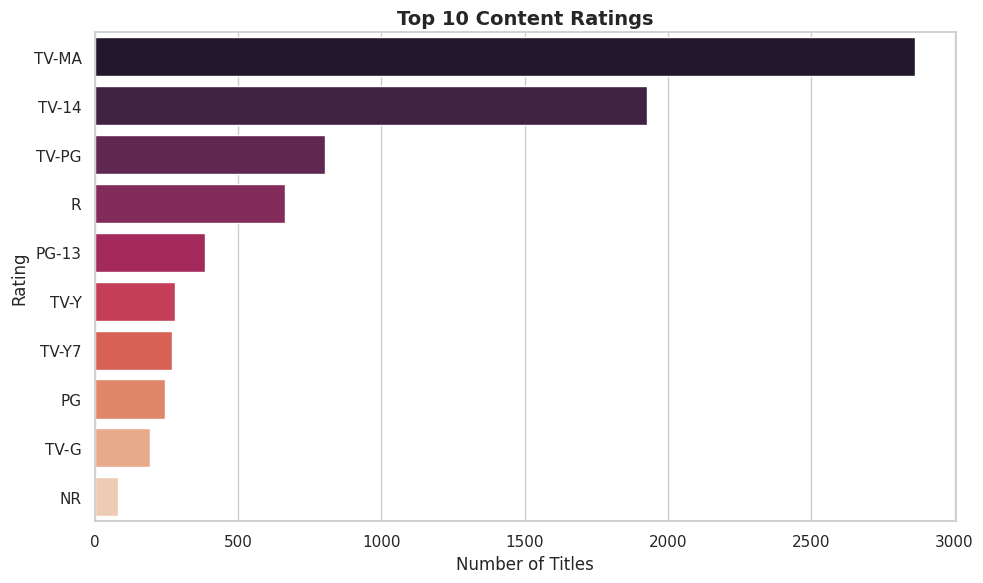

In [9]:
rating_counts = df["rating"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=rating_counts.values, y=rating_counts.index, hue=rating_counts.index,
            palette="rocket", legend=False)
plt.title("Top 10 Content Ratings", fontsize=14, weight="bold")
plt.xlabel("Number of Titles"); plt.ylabel("Rating")
plt.tight_layout()
plt.show()

### 4.5 Top 10 Genres

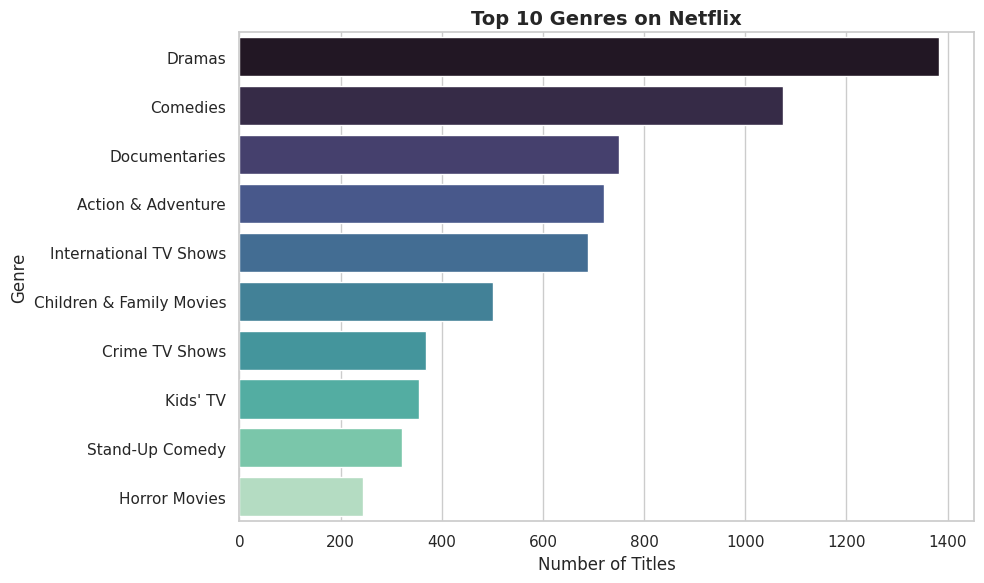

In [10]:
top_genres = df["primary_genre"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index,
            palette="mako", legend=False)
plt.title("Top 10 Genres on Netflix", fontsize=14, weight="bold")
plt.xlabel("Number of Titles"); plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### 4.6 Movie Duration Distribution

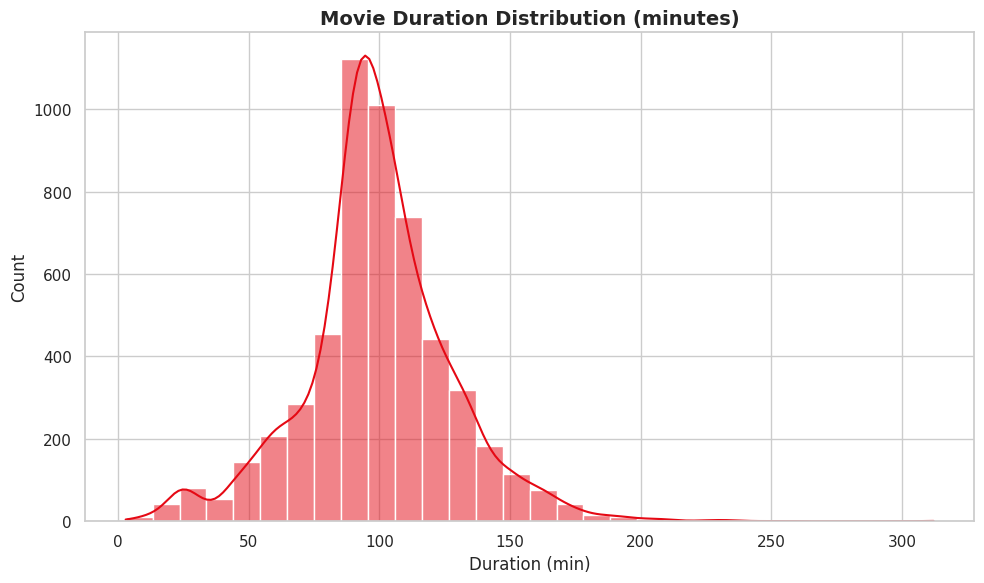

In [11]:
movie_durations = df[df["type"] == "Movie"]["duration_value"]
plt.figure(figsize=(10,6))
sns.histplot(movie_durations, bins=30, color="#E50914", kde=True)
plt.title("Movie Duration Distribution (minutes)", fontsize=14, weight="bold")
plt.xlabel("Duration (min)"); plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 4.7 Monthly Content Addition Pattern

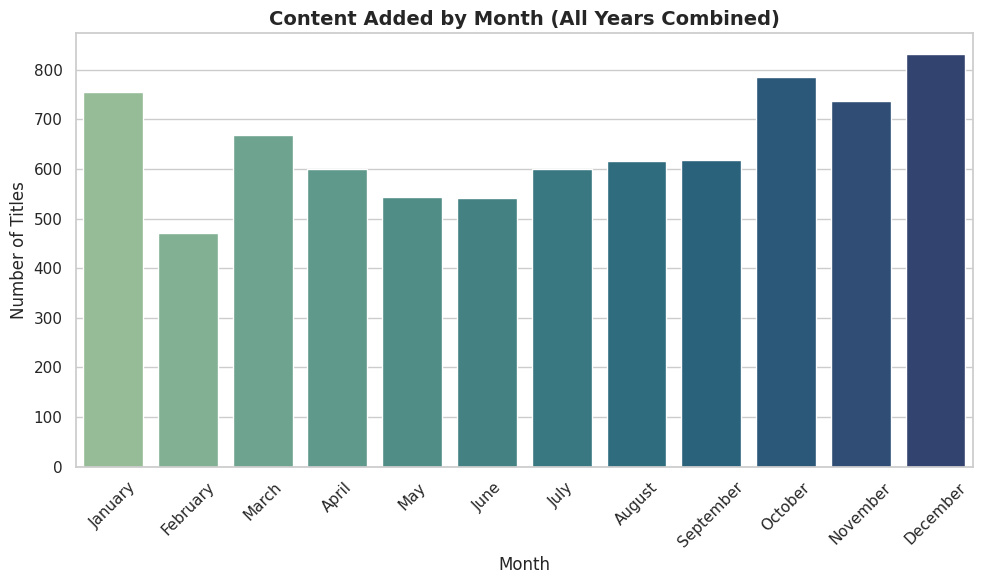

In [12]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
monthly = df["month_added"].value_counts().reindex(month_order)
plt.figure(figsize=(10,6))
sns.barplot(x=monthly.index, y=monthly.values, hue=monthly.index, palette="crest", legend=False)
plt.title("Content Added by Month (All Years Combined)", fontsize=14, weight="bold")
plt.xlabel("Month"); plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Key Business Insights

- Netflix's catalog is **~69% Movies and ~31% TV Shows** — movies still dominate, but the TV Show share has grown steadily since 2016 as Netflix invested more in original series.
- **2019 was the peak year** for content additions, after which growth slowed — consistent with Netflix shifting from aggressive licensing to originals-focused strategy.
- The **United States** is the single largest content-producing country by a wide margin, followed by India and the UK — showing Netflix's continued reliance on US content even as it globalizes.
- **Dramas** and **International Movies/TV Shows** are the most common genre tags, reflecting demand for both mainstream and localized content.
- **TV-MA** is the most frequent content rating, indicating Netflix's catalog skews toward mature audiences.
- The average movie runtime is about **99 minutes**, in line with typical theatrical/streaming feature lengths.
- **December** sees the most content additions of any month — likely tied to holiday-season viewing demand.
